In [1]:
import functions as mf
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from spleaf import cov, term
import emcee

<ErrorbarContainer object of 3 artists>

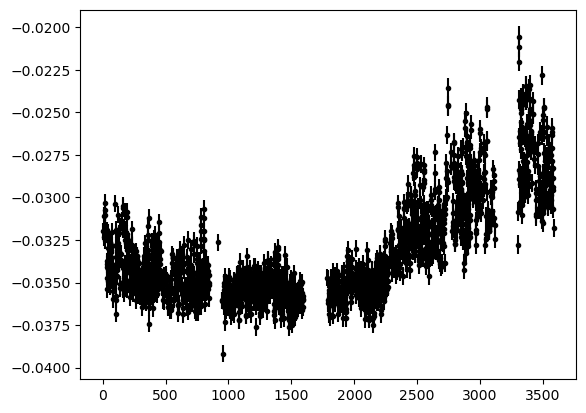

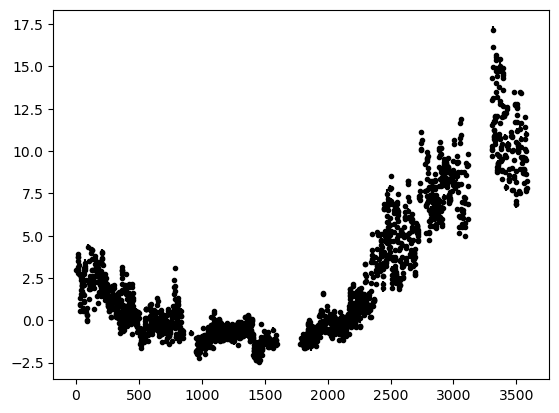

In [2]:
t_full, y_full, yerr_full, series_index = mf.load_and_norm_data("Solar Data", "Sun",normalise=False, inject_planet=False, planet_params=(40, 0.001, 0.004))

plt.figure()
plt.errorbar(t_full[series_index[0]], y_full[series_index[0]], yerr_full[series_index[0]], fmt='.', color='k')
plt.figure()
plt.errorbar(t_full[series_index[1]], y_full[series_index[1]], yerr_full[series_index[1]], fmt='.', color='k')


Shared parameters:
b    = -0.0006970727601800314
P    = 3730.4410820254284
phi  = -1.2763163829482949


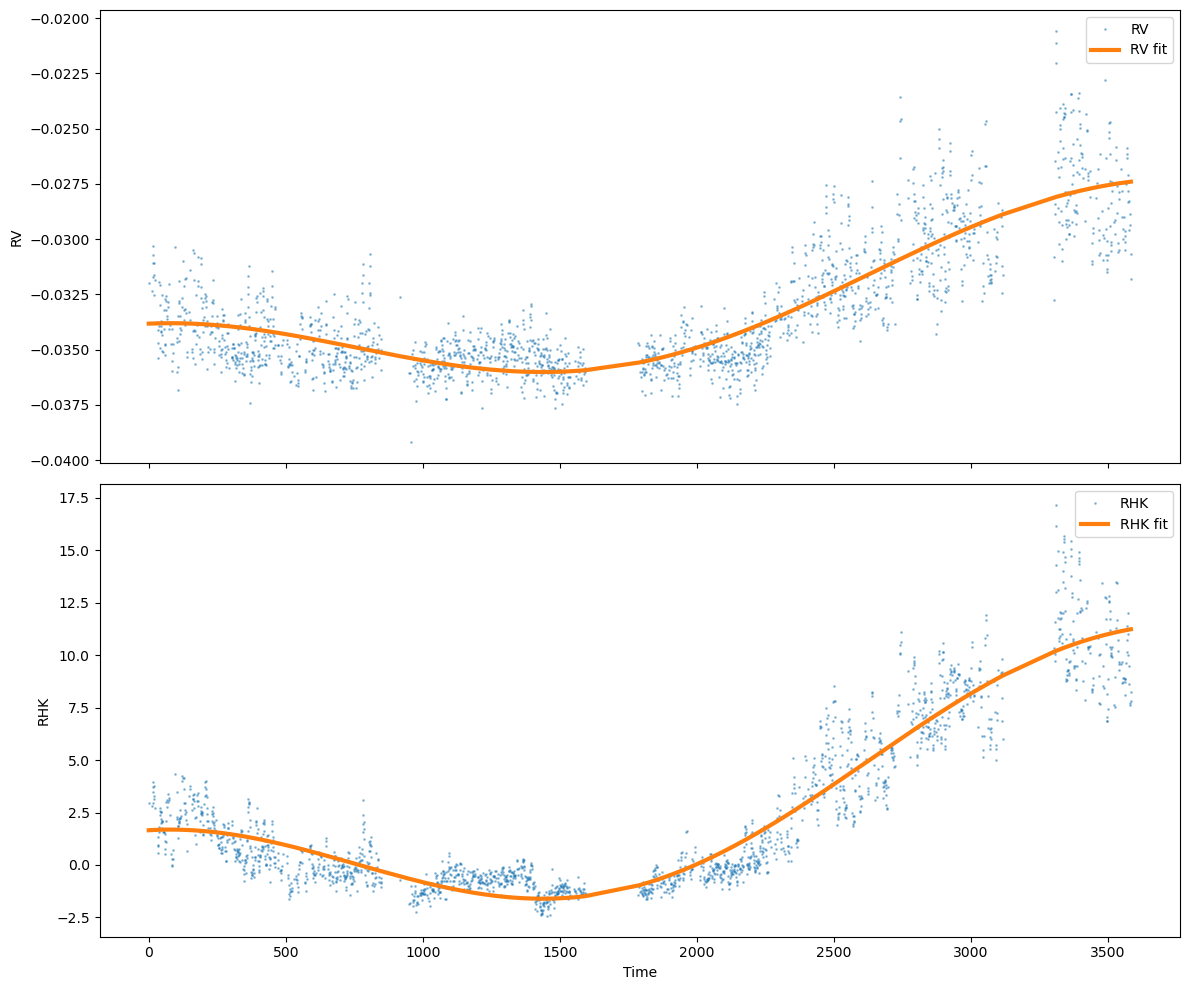

In [3]:
rv_fit, rhk_fit = mf.fit_cycle(t_full, y_full, series_index, plot=True, print_results=True)

In [4]:
y_full[series_index[0]] = y_full[series_index[0]] - rv_fit
y_full[series_index[1]] = y_full[series_index[1]] - rhk_fit

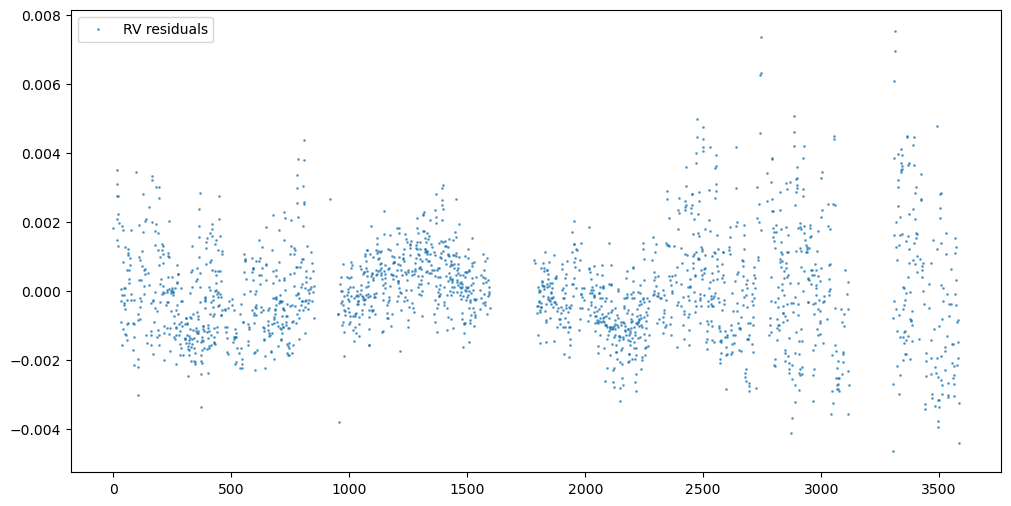

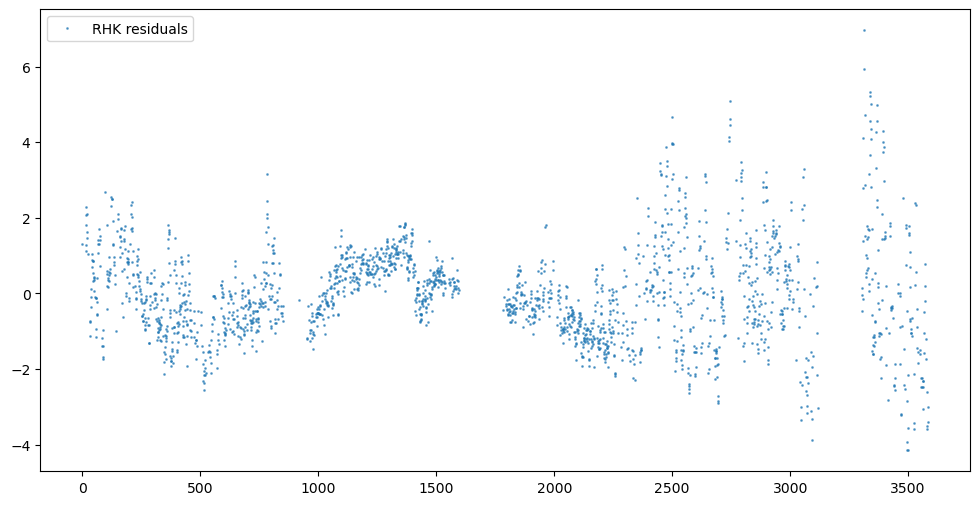

In [5]:
plt.figure(figsize=(12,6))
plt.plot(t_full[series_index[0]], y_full[series_index[0]], '.', alpha=0.6, markersize=2, label='RV residuals')
plt.legend()

plt.figure(figsize=(12,6))
plt.plot(t_full[series_index[1]], y_full[series_index[1]], '.', alpha=0.6, markersize=2, label='RHK residuals')
plt.legend()    

In [6]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

In [7]:
stds = [np.std(y_full[series_index[0]]), np.std(y_full[series_index[1]])]
# sig = np.var(y_full[series_index[0]]) 
sig = 1.0

prot = 27.0
Q = 1.2

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

rho = 60.0
eta = 0.25



C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  rot = MultiSeriesKernel(term.MEPKernel(sig,prot,rho,eta), series_index, 
        np.array([stds[0], stds[1]]), 
        np.array([stds[0], 0.0])
    ),
  )



In [8]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 20.0
prot_max = 32.0
Q_min = 0.9
Q_max = 3.0

alpha_0_max = 10*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 10*stds[0]

rho_min = 10.0
rho_max = 100.0
eta_min = 0.1
eta_max = 2.0

gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

planet_p_min = 30.0
planet_p_max = 50.0
planet_A_min = 0.0001
planet_A_max = 0.01
planet_B_min = 0.0001
planet_B_max = 0.01

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    
    (prot_min, prot_max),                 # rot.P0 (period)
    # (Q_min, Q_max),                      # rot.Q (quality factor)
    (rho_min, rho_max),                    # rot.rho (frequency)
    (eta_min, eta_max),                    # rot.eta (damping)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    # (0.01,0.99), 
    (-0.5, 0.5),         # delta_0 (offset for series 0)
    (-5,5),    
    # (planet_p_min, planet_p_max),                         # P_planet
    # (planet_A_min, planet_A_max),                          # A_planet
    # (planet_B_min, planet_B_max),                          # B_planet

]

# print(rvjit_max)
# print(rhkjit_max)
# print(alpha_0_max)
# print(bounds_list)

In [9]:
from scipy.optimize import fmin_l_bfgs_b


params_inds = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1"]  
params = [C.param[k] for k in params_inds]

x0 = C.get_param(params)
x0 = np.append(x0,[0.001, 0.001])   # Added initial guesses for new parameters (delta_0, delta_1, planet parameters)

result = fmin_l_bfgs_b(mf.negloglike_nocyc, x0, args=(t_full, y_full, series_index,C, 1.0, False), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'rot.P', 'rot.rho', 'rot.eta', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0']
[7.31531256e-04 2.44970045e-01 2.68447009e+01 5.99316912e+01
 4.34873552e-01 1.20281166e-03 1.36624839e+00 1.62418476e-03
 1.04022091e-04 1.11676010e-01]


In [10]:
xbest, C = mf.optimise_params(t_full, y_full, series_index, C, bounds_list, 1.0, fit_planet = False)
print(xbest)

[ 8.11753178e-04  0.00000000e+00  2.22989237e+01  1.00000000e+01
  2.06713422e-01  1.62069572e-03  1.93257732e+00  1.12581133e-03
 -1.91891974e-05 -2.78706296e-02]


(array([   0.        ,    3.58753262,    7.17506525,   10.76259787,
          14.35013049,   17.93766311,   21.52519574,   25.11272836,
          28.70026098,   32.28779361,   35.87532623,   39.46285885,
          43.05039148,   46.6379241 ,   50.22545672,   53.81298934,
          57.40052197,   60.98805459,   64.57558721,   68.16311984,
          71.75065246,   75.33818508,   78.92571771,   82.51325033,
          86.10078295,   89.68831557,   93.2758482 ,   96.86338082,
         100.45091344,  104.03844607,  107.62597869,  111.21351131,
         114.80104394,  118.38857656,  121.97610918,  125.5636418 ,
         129.15117443,  132.73870705,  136.32623967,  139.9137723 ,
         143.50130492,  147.08883754,  150.67637017,  154.26390279,
         157.85143541,  161.43896803,  165.02650066,  168.61403328,
         172.2015659 ,  175.78909853,  179.37663115,  182.96416377,
         186.55169639,  190.13922902,  193.72676164,  197.31429426,
         200.90182689,  204.48935951,  208.07689

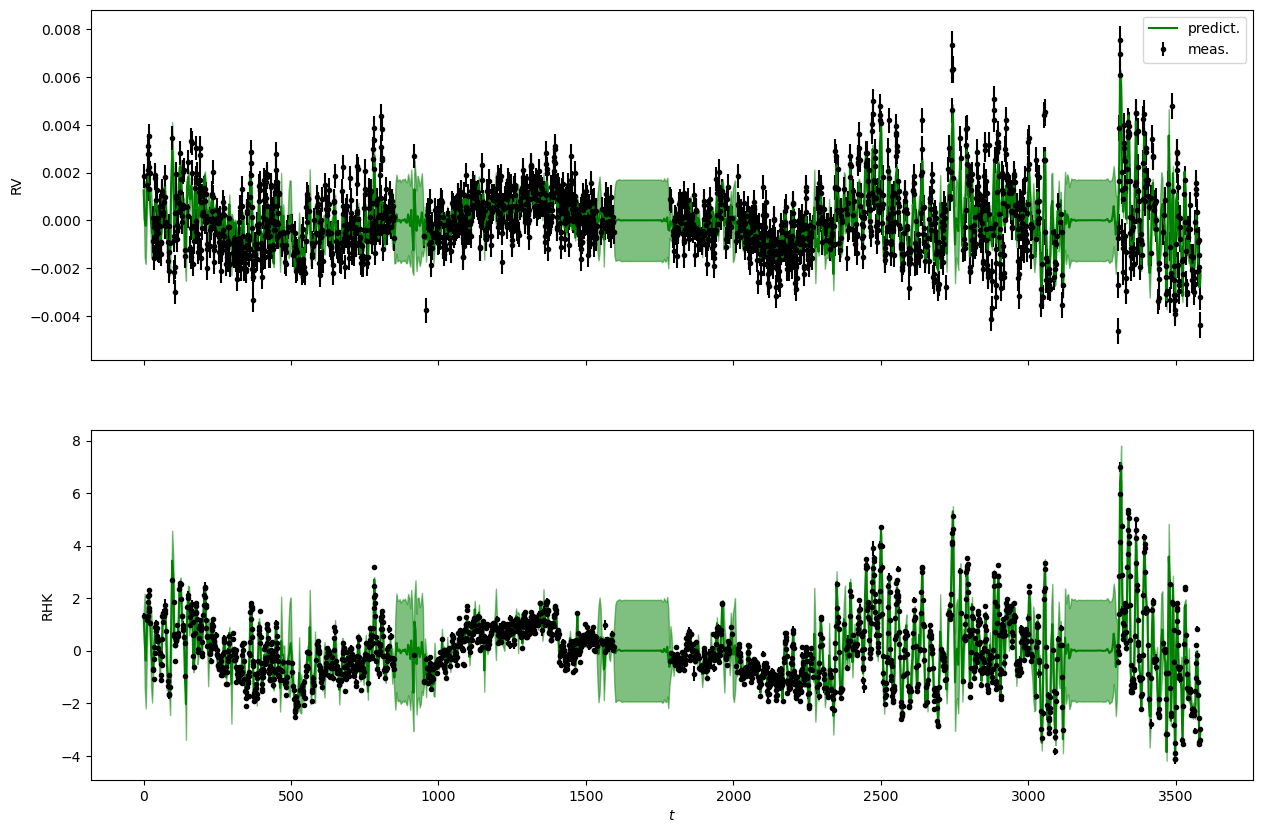

In [11]:
mf.plot_fit(t_full, y_full, yerr_full, series_index, C, xbest, inject_planet=False)

In [28]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1, planet_period, planet_A, planet_B = theta
    # if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -0.5 < delta_0 < 0.5 and -2 < delta_1 < 2 and planet_p_min < planet_period < planet_p_max and planet_A_min < planet_A < planet_A_max and planet_B_min < planet_B < planet_B_max:
    rv_jit, rhk_jit, rot_P0, rot_rho, rot_eta, rot_alpha_0, rot_alpha_1, rot_beta_0, delta_0, delta_1 = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and prot_min < rot_P0 < prot_max and rho_min < rot_rho < rho_max and eta_min < rot_eta < eta_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -0.5 < delta_0 < 0.5 and -2 < delta_1 < 2:
        return 0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*mf.negloglike_nocyc(theta, t_full, y, series_index, C, 1.0, False)[0]

x0 = xbest.copy()

# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-5 * np.random.randn(ndim*3, ndim)
# pos = x0 
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 3000, progress=True);

[ 0.00000000e+00  3.87499823e-01  2.64543300e+01  6.34649085e+01
  8.17509143e-01  2.57547820e-03  3.67742427e+00  7.65080375e-03
 -3.55584618e-02 -7.95658659e-01]
-inf


  0%|          | 0/3000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  3%|▎         | 94/3000 [00:14<07:48,  6.21it/s]Traceback (most recent call last):
  File "/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/var/folders/qb/bzz8k6cd16n1hv4_2j7_b3vm0000gp/T/ipykernel_10225/2048573160.py", line 14, in log_probability
    return lp + -1*mf.negloglike_nocyc(theta, t_full, y, series_index, C, 1.0, False)[0]
  File "/Users/tardugno/Documents/Oxford/planet_finder_model/functions.py", line 209, in negloglike_nocyc
    lg = C.loglike_grad()
  File "/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/spleaf/__init__.py", line 773, in loglike_grad
    self.cholesky_back()
  File "/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/spl

emcee: Exception while calling your likelihood function:
  params: [ 7.34477035e-04  3.92713089e-01  2.64575317e+01  6.34676454e+01
  8.16251207e-01  2.59486697e-03  3.67705692e+00  4.49600670e-03
 -3.56055833e-02 -7.96668796e-01]
  args: (array([-0.03200134,  2.95937007, -0.03235274, ...,  7.82623004,
       -0.03181068,  8.22940071], shape=(4120,)), <spleaf.cov.Cov object at 0x30cb1f6a0>)
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [70]:
sampler = mf.run_emcee(t_full, y_full, series_index, C, xbest, bounds_list, run_length = 2000, planet=False)

0


100%|██████████| 2000/2000 [07:20<00:00,  4.54it/s]  


IndexError: index 10 is out of bounds for axis 2 with size 10

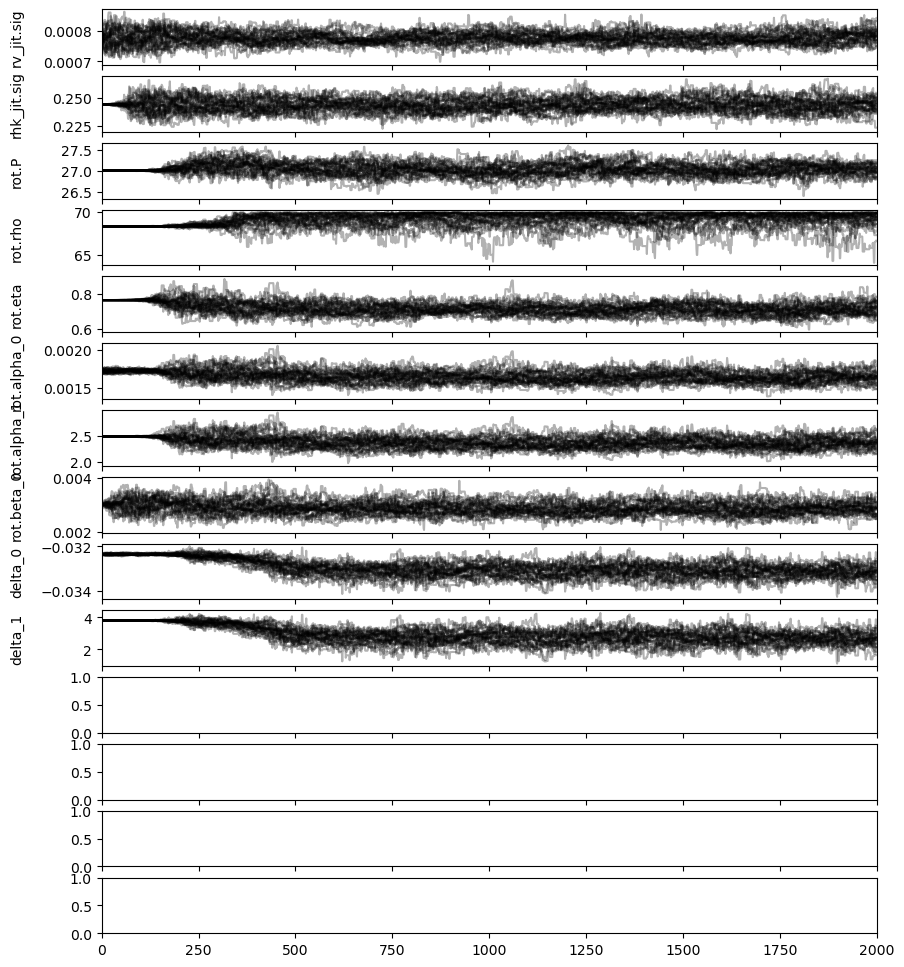

In [60]:
mf.plot_chains(sampler, C)

['rv_jit.sig', 'rhk_jit.sig', 'rot.P', 'rot.rho', 'rot.eta', 'rot.alpha_0', 'rot.alpha_1', 'rot.beta_0', 'delta_0', 'delta_1', 'planet_p', 'planet_A', 'planet_B']


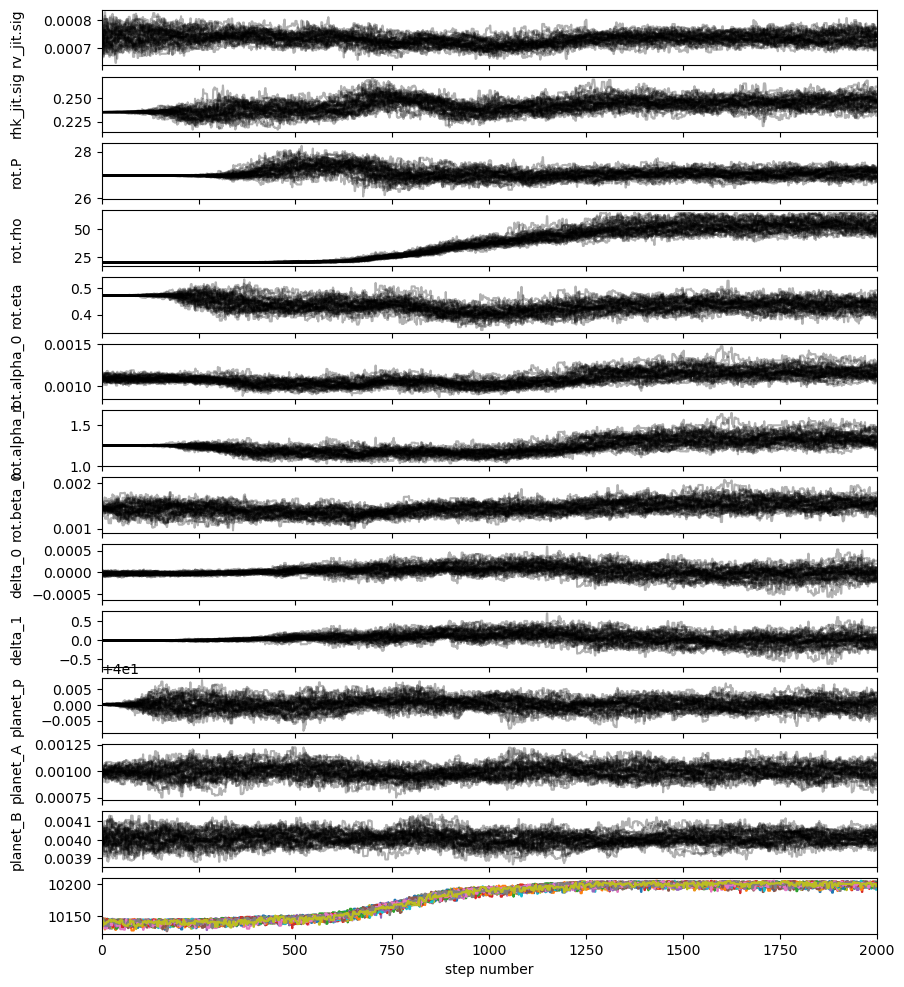

In [16]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)

params , _ = mf.get_opt_params(C)
ig, axes = plt.subplots(len(params) + 6, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

labels = params + ['delta_0', 'delta_1', 'planet_p', 'planet_A', 'planet_B']
# labels = params + ['pcyc','phi','k','gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(len(axes)-1):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

In [61]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=1, flat=True)

# true_vals = [0.0, 0.0, prot, Q, stds[0], stds[1], stds[0], 8000, np.pi, 0.28, gamma_0, gamma_1, delta_0, delta_1, 100.0, 0.5, 0.5]

fig = corner.corner(
    flat_samples, labels=labels, show_titles=True
);


NameError: name 'labels' is not defined

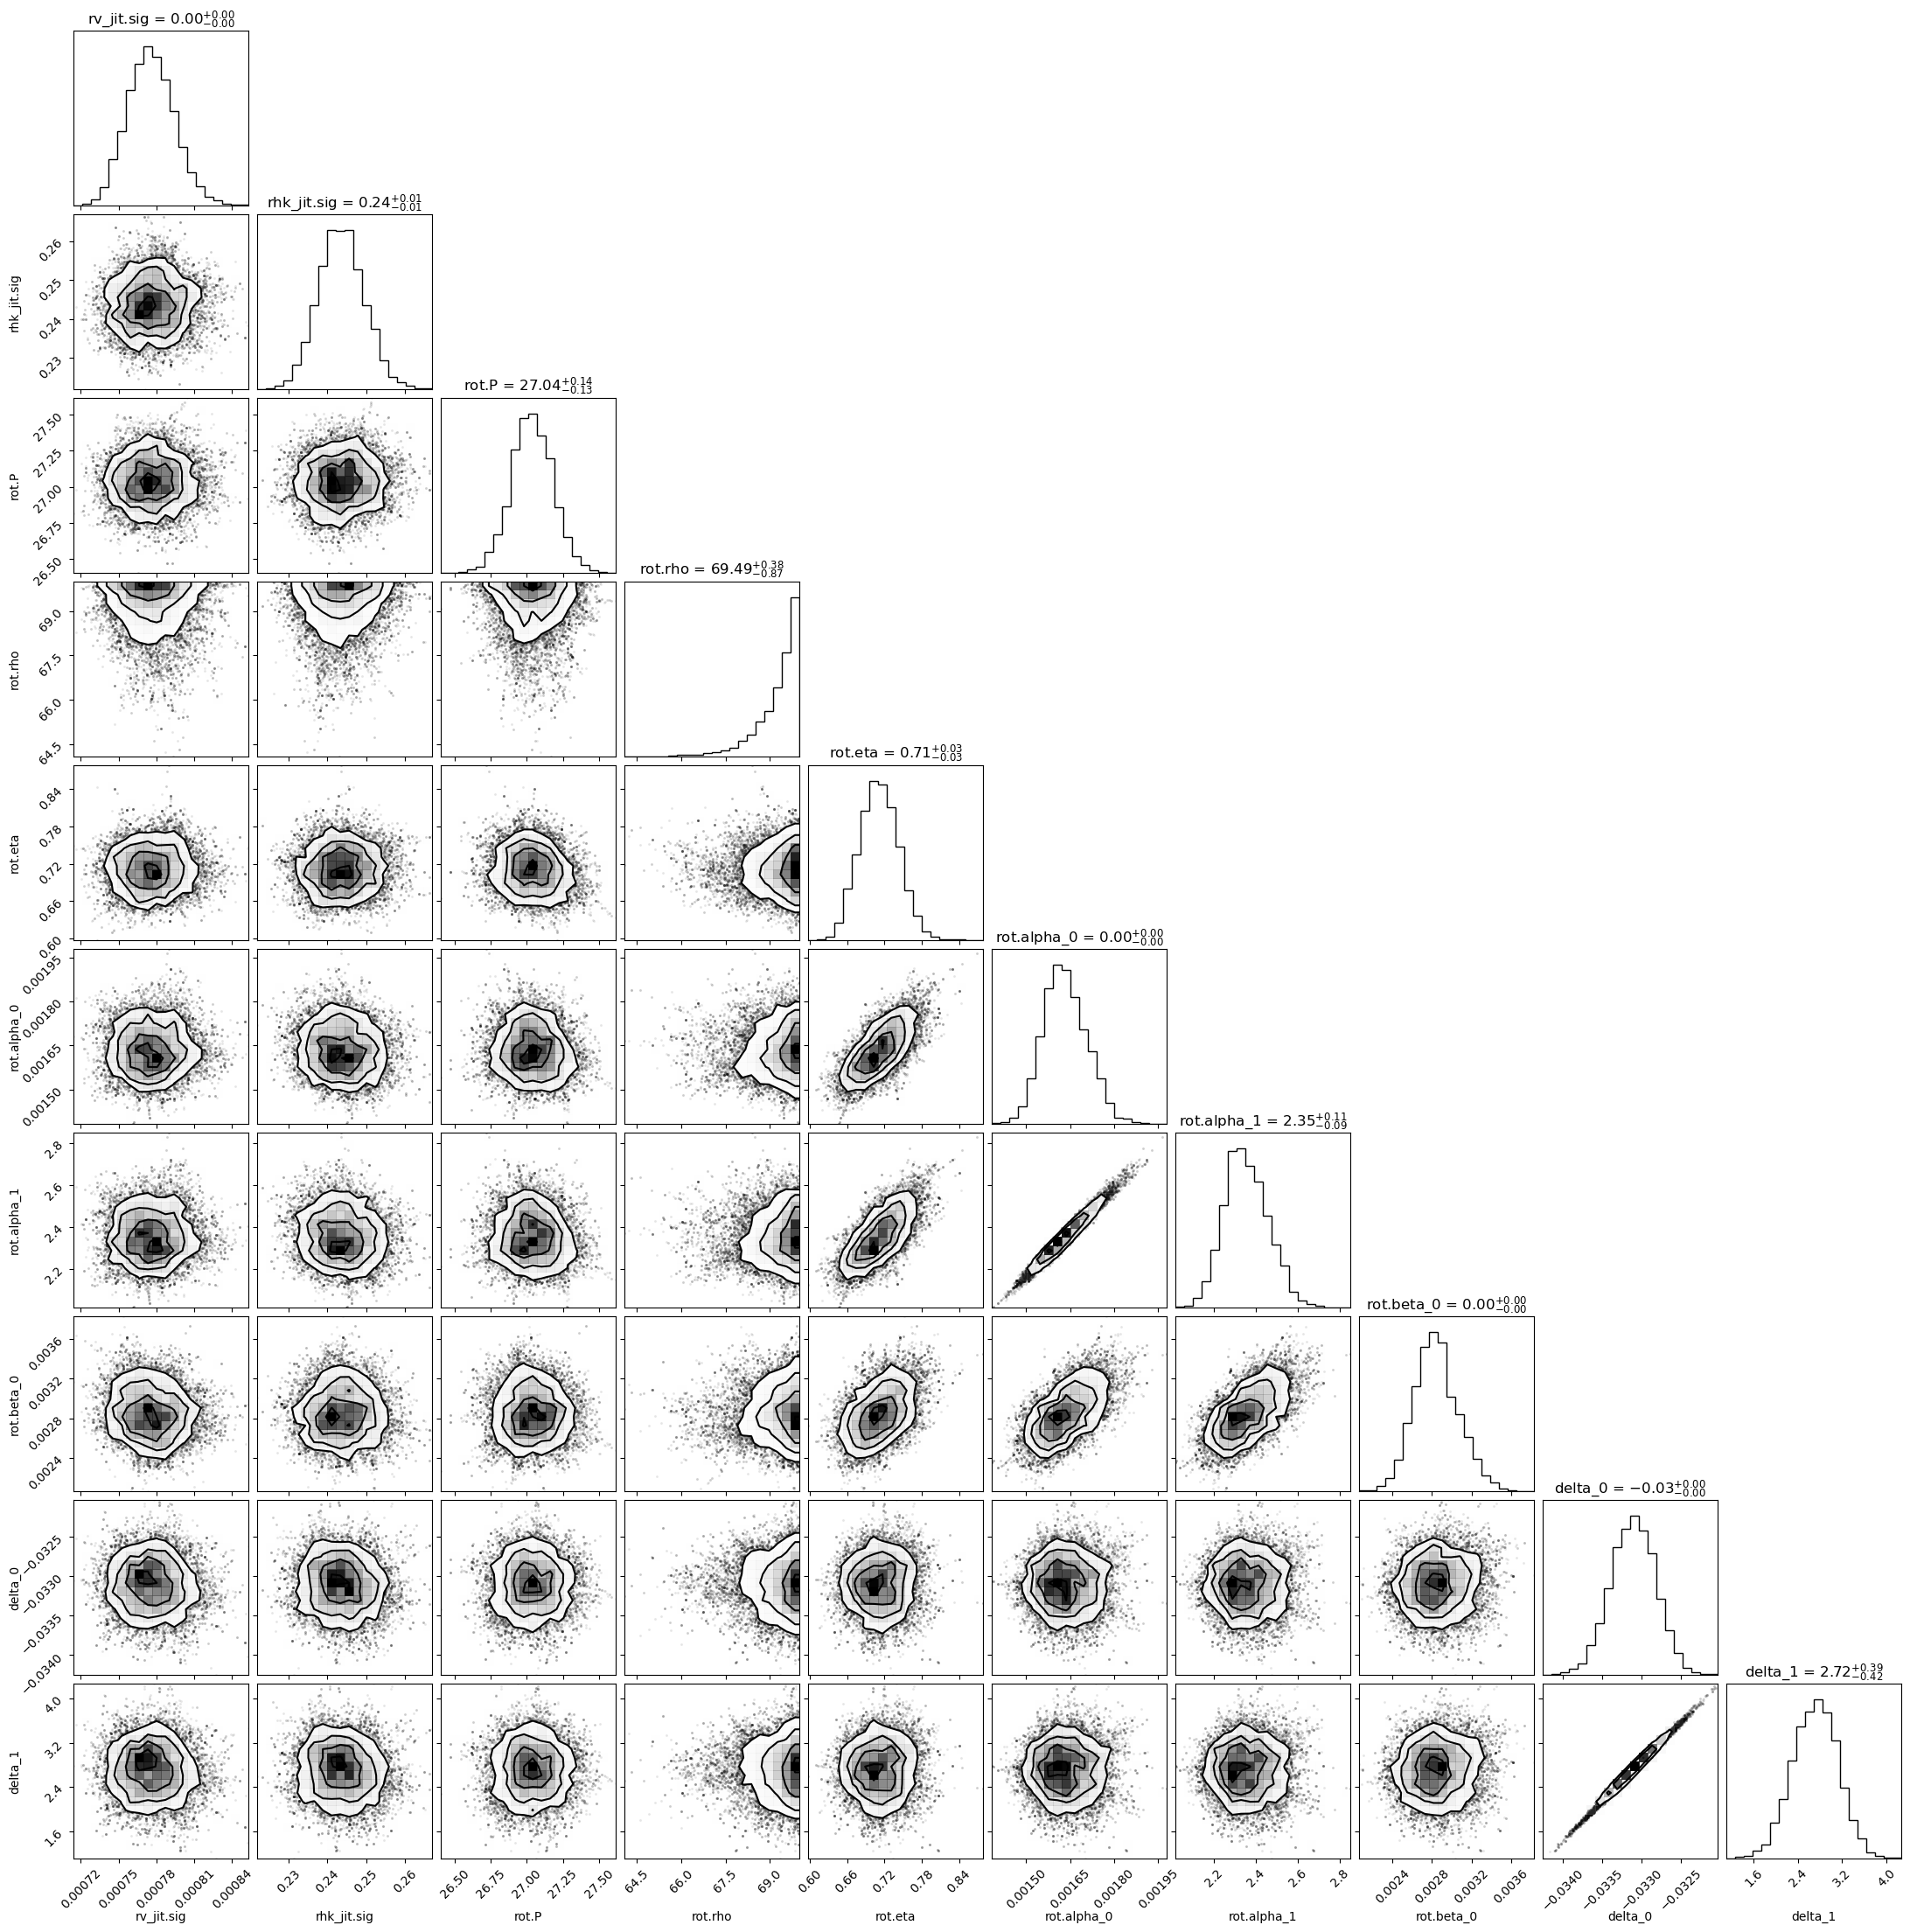

In [62]:
mf.plot_corner(sampler, C, planet=False)


MAP index (in flattened, post-burn chain): 33023
MAP log-posterior: 10217.556484360855
MAP sample (theta): [ 7.27298131e-04  2.42120789e-01  2.70769067e+01  5.12966820e+01
  4.33673881e-01  1.12766447e-03  1.28769939e+00  1.51499354e-03
 -3.66933025e-05 -3.73291590e-02  3.66094631e+02  1.36744087e-04
  5.80438199e-05]


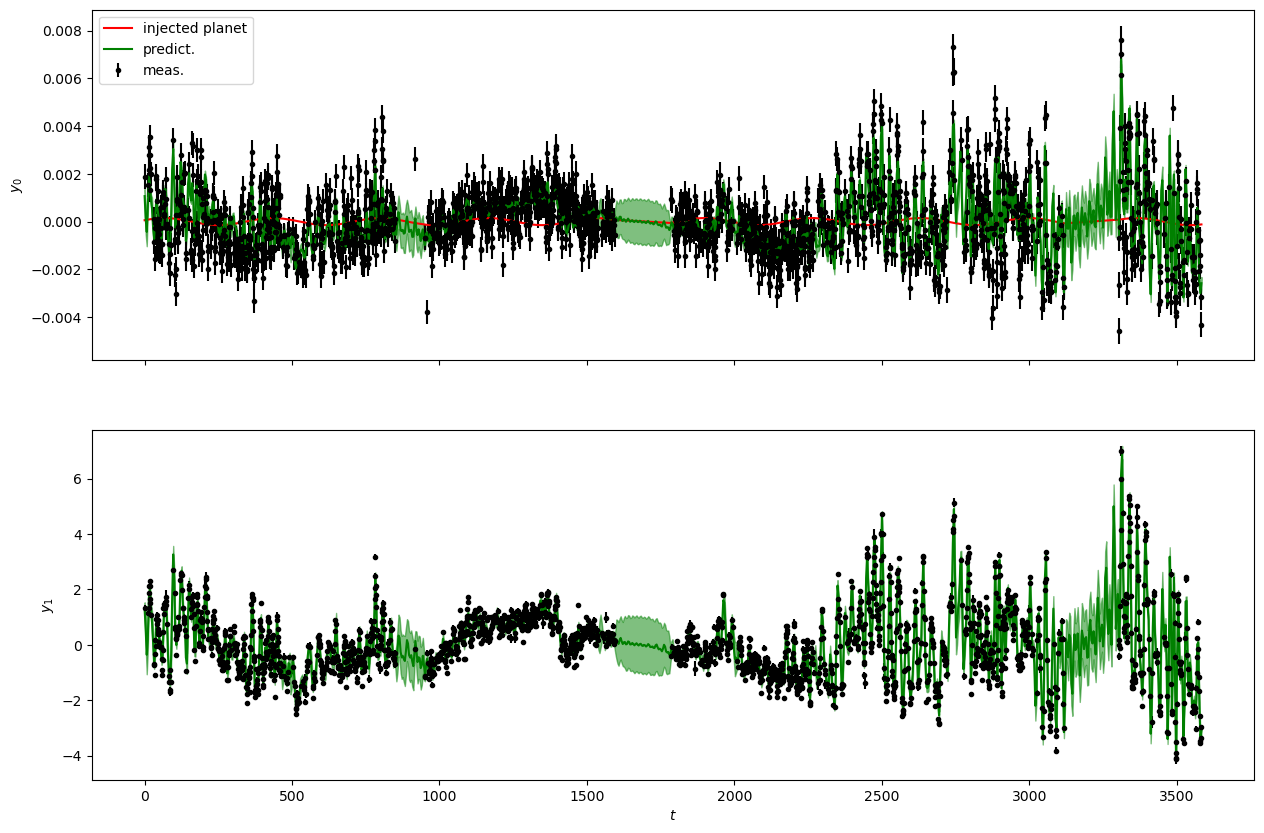

In [130]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample.npy", map_sample)

C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([np.var(y_full)], ['rot.sig'])

tsmooth, mu, res_rv, res_rhk = plot_fit(t_full, y_full, yerr_full, C, map_sample, series_index,1.0,output_name='fit_plot.png', return_residuals=True, inject_planet=True)

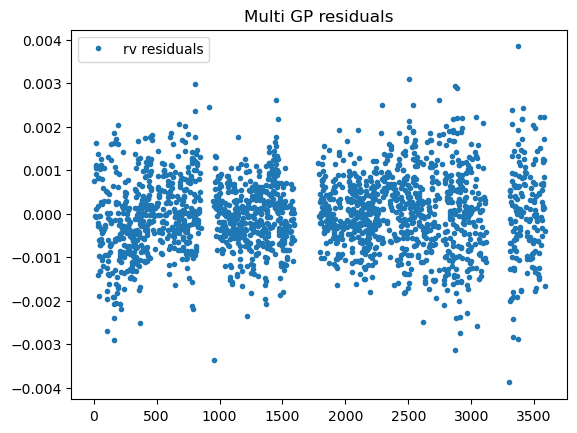

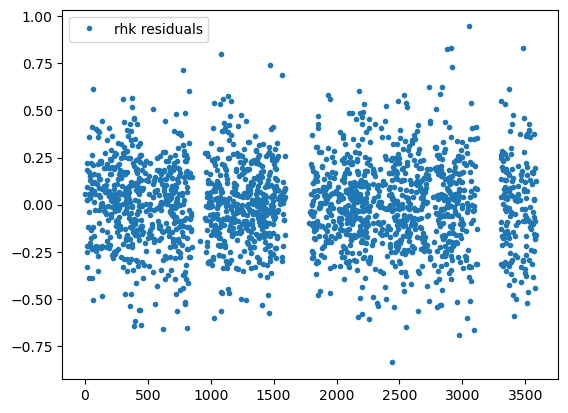

In [81]:
plt.figure()
plt.title("Multi GP residuals")
plt.plot(t_full[series_index[0]], res_rv, ".", label='rv residuals')
plt.legend()
plt.figure()
plt.plot(t_full[series_index[1]], res_rhk, ".", label='rhk residuals')
# plt.ylim(-1.5,1.5)
plt.legend()
plt.show()

In [82]:
(np.sqrt(map_sample[-2]**2 + map_sample[-1]**2) - np.sqrt(0.0001**2 + 0.0001**2)  )/ np.sqrt(0.0001**2 + 0.0001**2)

np.float64(0.011513130202136285)

In [49]:
np.sqrt(0.0005**2 + 0.0005**2)  

np.float64(0.0007071067811865475)